Problem 6

(6b) Cobweb diagrams
Saving tent_cobweb_2_5.png


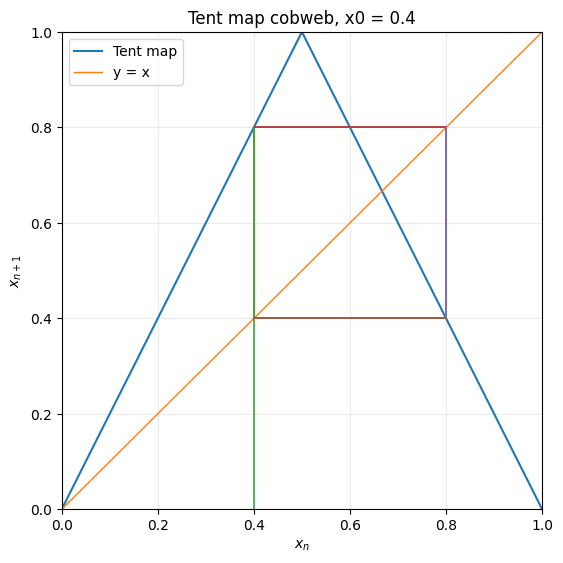

Saving tent_cobweb_2_9.png


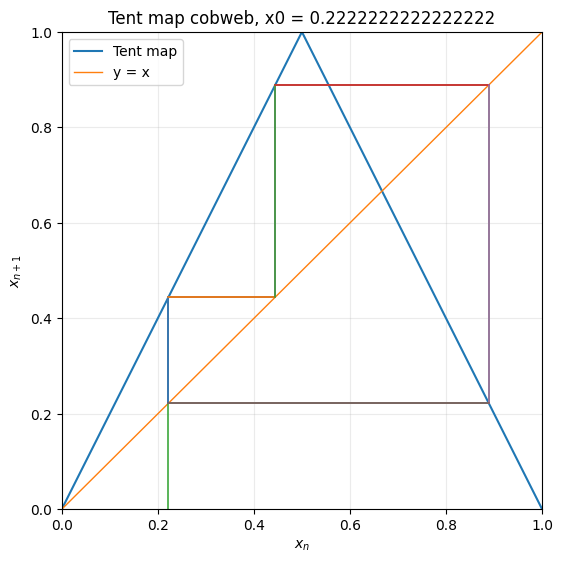


(6c) Floating-point values x_1001 through x_1005
For x0 = 2/5:
x_1001 = 0.0
x_1002 = 0.0
x_1003 = 0.0
x_1004 = 0.0
x_1005 = 0.0

For x0 = 2/9:
x_1001 = 0.0
x_1002 = 0.0
x_1003 = 0.0
x_1004 = 0.0
x_1005 = 0.0

(6d) Comparison with exact calculation
Exact orbit for x0 = 2/5:
x0, x1, ..., x6 = [Fraction(2, 5), Fraction(4, 5), Fraction(2, 5), Fraction(4, 5), Fraction(2, 5), Fraction(4, 5), Fraction(2, 5)]

Exact orbit for x0 = 2/9:
x0, x1, ..., x6 = [Fraction(2, 9), Fraction(4, 9), Fraction(8, 9), Fraction(2, 9), Fraction(4, 9), Fraction(8, 9), Fraction(2, 9)]

First n with x_n = 0.0 in float arithmetic for x0 = 2/5: n = 54
First n with x_n = 0.0 in float arithmetic for x0 = 2/9: n = 54

Answer to (6d):
No. The computer simulations are not consistent with the exact calculation.
Exact arithmetic gives
 x0 = 2/5 -> period-2 orbit: {2/5, 4/5}
 x0 = 2/9 -> period-3 orbit: {2/9, 4/9, 8/9}
but floating-point arithmetic drives both orbits to x_n = 0.0.


In [1]:
# ###########################################################################
# Author: Edward E. Daisey
# Course: Modeling & Simulation of Complex Systems
# Title: Assignment 10 - Problem 6
# Date: 7th of April 2026
# ###########################################################################

################################### Overview ##################################
# Description:
# This script studies the tent map
#
# T(x) = 2x for 0 <= x <= 1/2
# T(x) = 2 - 2x for 1/2 <= x <= 1
#
# for the two initial conditions
#
# x0 = 2/5
# x0 = 2/9
#
# It answers:
#
# (6b) Generate cobweb diagrams for x0 = 2/5 and x0 = 2/9
# (6c) Compute x_1001, ..., x_1005 for both initial conditions
# (6d) Decide whether the computer simulation is consistent with the
# exact calculation
#
# Output:
# (1) Terminal output labeled by subsection
# (2) Two saved cobweb figures:
# tent_cobweb_2_5.png
# tent_cobweb_2_9.png
# ###########################################################################

# ############################ Imports ######################################
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
# ###########################################################################

# ############################ Constants ####################################
initialConditionA = 2.0 / 5.0
initialConditionB = 2.0 / 9.0

exactInitialConditionA = Fraction(2, 5)
exactInitialConditionB = Fraction(2, 9)

cobwebSteps = 12
tailStart = 1001
tailEnd = 1005

outputFileA = "tent_cobweb_2_5.png"
outputFileB = "tent_cobweb_2_9.png"
# ###########################################################################

# ############################ Function 1 ###################################
# Name:
# TentMap
#
# Purpose:
# Evaluates one step of the tent map in floating-point arithmetic.
#
# Input:
# x : Current state.
#
# Output:
# Next state T(x).
def TentMap(x):
    if x <= 0.5:
        return 2.0 * x
    return 2.0 - 2.0 * x
# ###########################################################################

# ############################ Function 2 ###################################
# Name:
# TentMapExact
#
# Purpose:
# Evaluates one step of the tent map in exact rational arithmetic.
#
# Input:
# x : Current state as a Fraction.
#
# Output:
# Next state T(x) as a Fraction.
def TentMapExact(x):
    if x <= Fraction(1, 2):
        return 2 * x
    return 2 - 2 * x
# ###########################################################################

# ############################ Function 3 ###################################
# Name:
# GenerateOrbit
#
# Purpose:
# Generates x0, x1, ..., xN in floating-point arithmetic.
#
# Input:
# initialCondition : Starting value x0.
# finalIndex : Largest iterate index N.
#
# Output:
# List [x0, x1, ..., xN].
def GenerateOrbit(initialCondition, finalIndex):
    orbitValues = [initialCondition]
    currentValue = initialCondition

    for _ in range(finalIndex):
        currentValue = TentMap(currentValue)
        orbitValues.append(currentValue)

    return orbitValues
# ###########################################################################

# ############################ Function 4 ###################################
# Name:
# GenerateExactOrbit
#
# Purpose:
# Generates x0, x1, ..., xN in exact rational arithmetic.
#
# Input:
# initialCondition : Starting value x0 as a Fraction.
# finalIndex : Largest iterate index N.
#
# Output:
# List [x0, x1, ..., xN].
def GenerateExactOrbit(initialCondition, finalIndex):
    orbitValues = [initialCondition]
    currentValue = initialCondition

    for _ in range(finalIndex):
        currentValue = TentMapExact(currentValue)
        orbitValues.append(currentValue)

    return orbitValues
# ###########################################################################

# ############################ Function 5 ###################################
# Name:
# PlotCobweb
#
# Purpose:
# Generates and saves a cobweb diagram for the tent map.
#
# Input:
# initialCondition : Starting value x0.
# numberOfSteps : Number of cobweb steps to draw.
# fileName : Output image filename.
#
# Output:
# Saved PNG image.
def PlotCobweb(initialCondition, numberOfSteps, fileName):
    xGrid = np.linspace(0.0, 1.0, 1200)
    yGrid = np.where(xGrid <= 0.5, 2.0 * xGrid, 2.0 - 2.0 * xGrid)

    plt.figure(figsize=(6.2, 6.2))
    plt.plot(xGrid, yGrid, linewidth=1.5, label="Tent map")
    plt.plot([0.0, 1.0], [0.0, 1.0], linewidth=1.0, label="y = x")

    currentX = initialCondition
    currentY = 0.0

    for _ in range(numberOfSteps):
        nextY = TentMap(currentX)
        plt.plot([currentX, currentX], [currentY, nextY], linewidth=1.1)
        plt.plot([currentX, nextY], [nextY, nextY], linewidth=1.1)
        currentX = nextY
        currentY = nextY

    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.0)
    plt.xlabel(r"$x_n$")
    plt.ylabel(r"$x_{n+1}$")
    plt.title(f"Tent map cobweb, x0 = {initialCondition}")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.savefig(fileName, dpi=220, bbox_inches="tight")
    plt.show()
# ###########################################################################

# ############################ Function 6 ###################################
# Name:
# FirstZeroIndex
#
# Purpose:
# Finds the first iterate index n for which x_n = 0.0 in floating-point
# arithmetic.
#
# Input:
# initialCondition : Starting value x0.
# searchLimit : Largest iterate index to check.
#
# Output:
# First index n with x_n = 0.0, or None if not found.
def FirstZeroIndex(initialCondition, searchLimit):
    currentValue = initialCondition

    if currentValue == 0.0:
        return 0

    for index in range(1, searchLimit + 1):
        currentValue = TentMap(currentValue)
        if currentValue == 0.0:
            return index

    return None
# ###########################################################################

# ############################ Function 7 ###################################
# Name:
# PrintTail
#
# Purpose:
# Prints x_start through x_end for one orbit.
#
# Input:
# orbitValues : List [x0, x1, ..., xN].
# startIndex : First requested index.
# endIndex : Last requested index.
# label : Description of the initial condition.
#
# Output:
# Terminal output.
def PrintTail(orbitValues, startIndex, endIndex, label):
    print(label)
    for index in range(startIndex, endIndex + 1):
        print(f"x_{index} = {orbitValues[index]}")
    print()
# ###########################################################################

# ############################ Function 8 ###################################
# Name:
# Main
#
# Purpose:
# Executes parts (6b), (6c), and (6d) with clear subsection labels.
#
# Input:
# None.
#
# Output:
# Terminal output and two cobweb plots.
def Main():
    orbitA = GenerateOrbit(initialConditionA, tailEnd)
    orbitB = GenerateOrbit(initialConditionB, tailEnd)

    exactOrbitA = GenerateExactOrbit(exactInitialConditionA, 6)
    exactOrbitB = GenerateExactOrbit(exactInitialConditionB, 6)

    zeroIndexA = FirstZeroIndex(initialConditionA, 5000)
    zeroIndexB = FirstZeroIndex(initialConditionB, 5000)

    print("Problem 6")
    print()

    print("(6b) Cobweb diagrams")
    print(f"Saving {outputFileA}")
    PlotCobweb(initialConditionA, cobwebSteps, outputFileA)
    print(f"Saving {outputFileB}")
    PlotCobweb(initialConditionB, cobwebSteps, outputFileB)
    print()

    print("(6c) Floating-point values x_1001 through x_1005")
    PrintTail(orbitA, tailStart, tailEnd, "For x0 = 2/5:")
    PrintTail(orbitB, tailStart, tailEnd, "For x0 = 2/9:")

    print("(6d) Comparison with exact calculation")
    print("Exact orbit for x0 = 2/5:")
    print("x0, x1, ..., x6 =", exactOrbitA)
    print()
    print("Exact orbit for x0 = 2/9:")
    print("x0, x1, ..., x6 =", exactOrbitB)
    print()
    print(f"First n with x_n = 0.0 in float arithmetic for x0 = 2/5: n = {zeroIndexA}")
    print(f"First n with x_n = 0.0 in float arithmetic for x0 = 2/9: n = {zeroIndexB}")
    print()
    print("Answer to (6d):")
    print("No. The computer simulations are not consistent with the exact calculation.")
    print("Exact arithmetic gives")
    print(" x0 = 2/5 -> period-2 orbit: {2/5, 4/5}")
    print(" x0 = 2/9 -> period-3 orbit: {2/9, 4/9, 8/9}")
    print("but floating-point arithmetic drives both orbits to x_n = 0.0.")
# ###########################################################################

# ############################# Execution ###################################
Main()
# ###########################################################################